# Import Libraries
This block imports the necessary libraries for data manipulation (pandas), model training and evaluation (sklearn), and model performance metrics.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import GridSearchCV

# Step 1: Load and Explore the Data
Loads the dataset Credit.csv into a DataFrame and displays the first few rows to understand its structure and content.

In [2]:
data = pd.read_csv('Credit.csv')
data.head()

,Credit,RevolvingUtiOfUnsecuredLines,age,DebtRatio,MonthlyIncome,NoOfDependents,NoRealEstateLoansOrLines,NoOfOpenCreditLinesAndLoans,NoofTime30_59DaysPastDue,NoOfTime60_89DaysPastDue,NorOfTimes90DaysLate
0,1,0.766127,45,0.802982,9120,2,6,13,2,0,0
1,0,0.957151,40,0.121876,2600,1,0,4,0,0,0
2,0,0.658180,38,0.085113,3042,0,0,2,1,0,1
3,0,0.233810,30,0.036050,3300,0,0,5,0,0,0
4,0,0.907239,49,0.024926,63588,0,1,7,1,0,0


# Step 2: Data Cleaning and Preprocessing
- Checks for any missing values in the dataset. Since there are no missing values in this dataset, you can proceed to the next steps.
- Separates the dataset into features (X) and the target variable (y). X includes all columns except 'Credit', which is the target variable y.
- Splits the data into training and testing sets, with 30% of the data reserved for testing. This allows for evaluating the model’s performance on unseen data. 
- Scales the features to have a mean of 0 and a standard deviation of 1, ensuring that all features contribute equally to the model training.

In [3]:
# Check for missing values
print(data.isnull().sum())

# In this dataset, there are no missing values, so we can proceed.

# Define features and target variable
X = data.drop('Credit', axis=1)
y = data['Credit']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Feature scaling (standardizing numerical features)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

Credit                          0
RevolvingUtiOfUnsecuredLines    0
age                             0
DebtRatio                       0
MonthlyIncome                   0
NoOfDependents                  0
NoRealEstateLoansOrLines        0
NoOfOpenCreditLinesAndLoans     0
NoofTime30_59DaysPastDue        0
NoOfTime60_89DaysPastDue        0
NorOfTimes90DaysLate            0
dtype: int64


# Step 3: Build the Decision Tree
- Creates and trains a Decision Tree classifier using the training data. The random_state ensures reproducibility of results.

In [4]:
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train_scaled, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

# Step 4: Evaluate the Model
- Makes predictions on the train and test data and evaluates the model’s performance. The accuracy_score provides the overall accuracy, while classification_report offers detailed metrics like precision, recall, and F1-score.

In [5]:
y_train_pred = clf.predict(X_train_scaled)
print("Accuracy Score:", accuracy_score(y_train, y_train_pred))
print("Classification Report:")
print(classification_report(y_train, y_train_pred))

y_test_pred = clf.predict(X_test_scaled)
print("Accuracy Score:", accuracy_score(y_test, y_test_pred))
print("Classification Report:")
print(classification_report(y_test, y_test_pred))

Accuracy Score: 1.0
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5240
           1       1.00      1.00      1.00       378

    accuracy                           1.00      5618
   macro avg       1.00      1.00      1.00      5618
weighted avg       1.00      1.00      1.00      5618

Accuracy Score: 0.8700166112956811
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.91      0.93      2269
           1       0.10      0.17      0.13       139

    accuracy                           0.87      2408
   macro avg       0.53      0.54      0.53      2408
weighted avg       0.90      0.87      0.88      2408



### Based on above result the Model looks overfitted.

# Visualize the Decision Tree (requires graphviz)

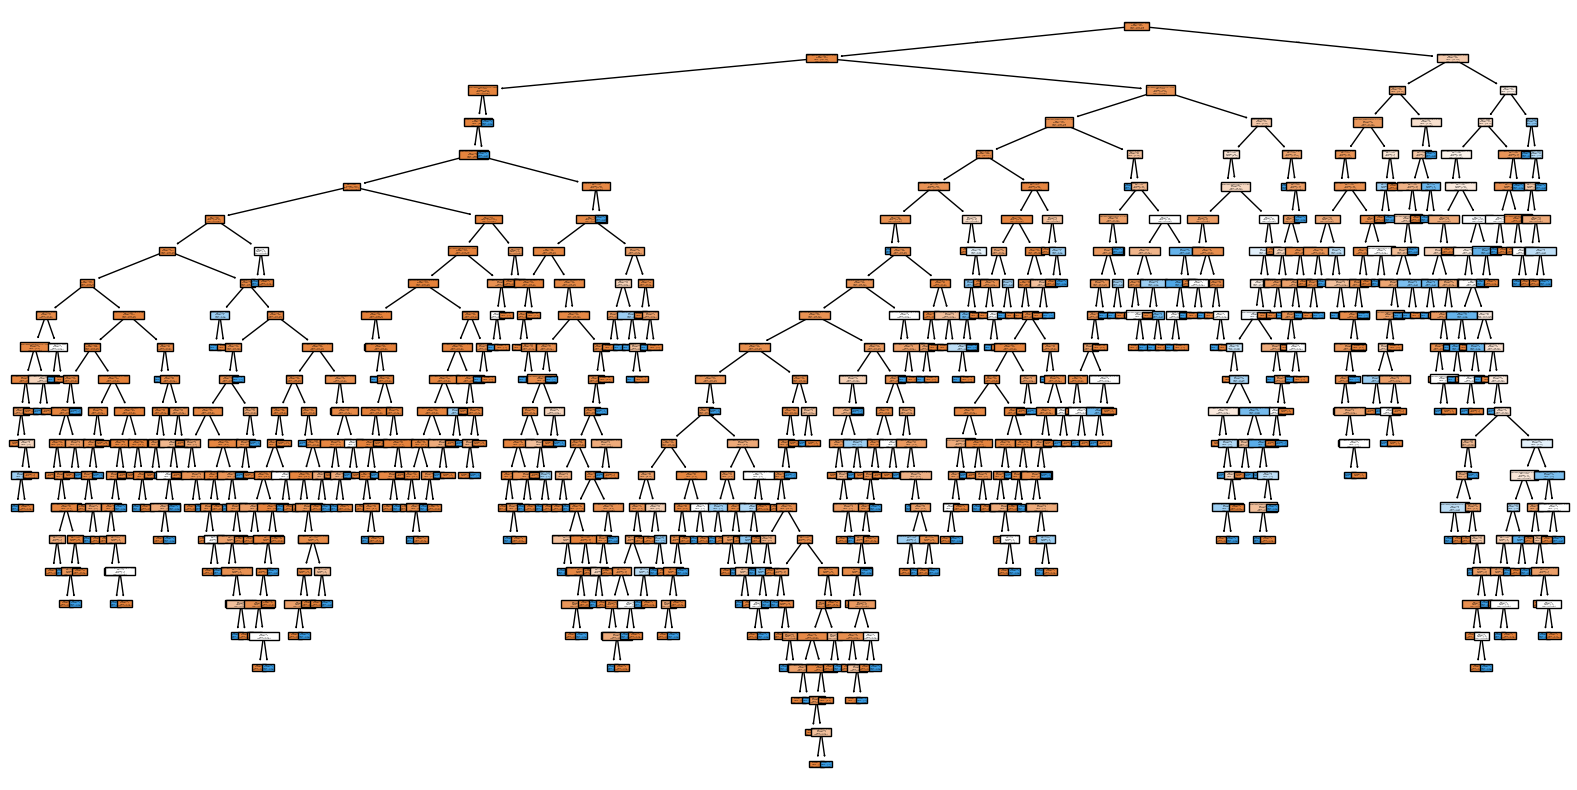

In [6]:
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
tree.plot_tree(clf, feature_names=X.columns, class_names=['Not Default', 'Default'], filled=True)
plt.show()



# Pruning the tree

In [7]:
clf = DecisionTreeClassifier(random_state=42,min_samples_split=10,min_samples_leaf=12,max_depth=20)
clf.fit(X_train_scaled, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",12
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

# Evaluate the model

In [8]:
y_train_pred = clf.predict(X_train_scaled)
print("Accuracy Score:", accuracy_score(y_train, y_train_pred))
print("Classification Report:")
print(classification_report(y_train, y_train_pred))

y_test_pred = clf.predict(X_test_scaled)
print("Accuracy Score:", accuracy_score(y_test, y_test_pred))
print("Classification Report:")
print(classification_report(y_test, y_test_pred))

Accuracy Score: 0.9446422214311143
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      5240
           1       0.69      0.32      0.44       378

    accuracy                           0.94      5618
   macro avg       0.82      0.65      0.70      5618
weighted avg       0.94      0.94      0.93      5618

Accuracy Score: 0.9422757475083057
Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97      2269
           1       0.50      0.01      0.01       139

    accuracy                           0.94      2408
   macro avg       0.72      0.50      0.49      2408
weighted avg       0.92      0.94      0.92      2408



# Visualize the Decision Tree (requires graphviz)

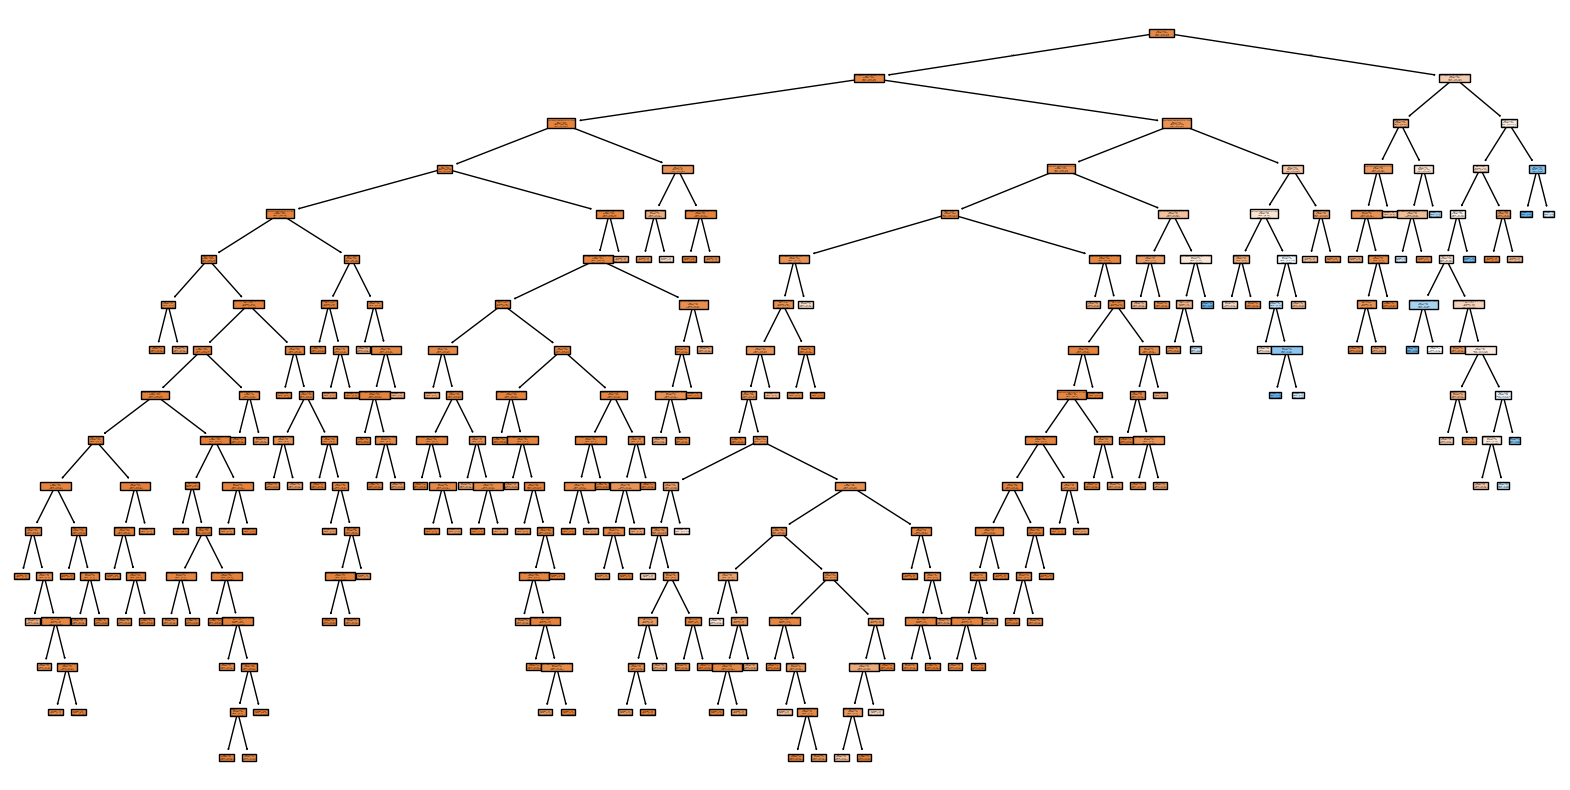

In [9]:
plt.figure(figsize=(20,10))
tree.plot_tree(clf, feature_names=X.columns, class_names=['Not Default', 'Default'], filled=True)
plt.show()



# Hyperparameter Tuning

In [11]:
# Define the parameter grid for hyperparameter tuning
param_grid = {
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize the Decision Tree Classifier
clf = DecisionTreeClassifier(random_state=42)

# Initialize GridSearchCV with the parameter grid
grid_search = GridSearchCV(estimator=clf, param_grid=param_grid, cv=5, scoring='accuracy')

# Fit GridSearchCV
grid_search.fit(X_train_scaled, y_train)

# Get the best parameters and the best model
best_params = grid_search.best_params_
best_clf = grid_search.best_estimator_

print("Best Parameters:", best_params)

Best Parameters: {'min_samples_leaf': 2, 'min_samples_split': 10}
